In [1]:
import pandas as pd 


In [2]:
liar = pd.read_csv("Documents/train.tsv" ,sep="\t",header=None)

In [3]:
fake = pd.read_csv("Documents/Fake.csv")
true = pd.read_csv("Documents/True.csv")

In [4]:
print (liar.shape)
print (fake.shape)
print (true.shape)

(10240, 14)
(23481, 4)
(21417, 4)


In [5]:
liar.head

<bound method NDFrame.head of                0            1   \
0       2635.json        false   
1      10540.json    half-true   
2        324.json  mostly-true   
3       1123.json        false   
4       9028.json    half-true   
...           ...          ...   
10235   5473.json  mostly-true   
10236   3408.json  mostly-true   
10237   3959.json    half-true   
10238   2253.json        false   
10239   1155.json   pants-fire   

                                                      2   \
0      Says the Annies List political group supports ...   
1      When did the decline of coal start? It started...   
2      Hillary Clinton agrees with John McCain "by vo...   
3      Health care reform legislation is likely to ma...   
4      The economic turnaround started at the end of ...   
...                                                  ...   
10235  There are a larger number of shark attacks in ...   
10236  Democrats have now become the party of the [At...   
10237  Says an altern

In [6]:
liar_cols = [
    "id", "label", "statement", "subject", "speaker", "speaker_job",
    "state", "party", "barely_true_count", "false_count",
    "half_true_count", "mostly_true_count", "pants_fire_count", "context"
]
liar.columns = liar_cols

label_map = {
    "true": "Reliable", "mostly-true": "Reliable",
    "half-true": "Suspicious", "barely-true": "Suspicious",
    "false": "Misinformation", "pants-fire": "Misinformation",
}
liar["new_label"] = liar["label"].map(label_map)

liar_df = liar[["statement", "new_label"]].copy()
liar_df.columns = ["text", "label"]
liar_df["source"] = "LIAR"

# Fake / True dataset
fake["label"] = "Misinformation"
true["label"] = "Reliable"

fake_df = fake[["text", "label"]].copy()
true_df = true[["text", "label"]].copy()
fake_df["source"] = "Kaggle_Fake"
true_df["source"] = "Kaggle_True"

# Combine
final_df = pd.concat([liar_df, fake_df, true_df], ignore_index=True)
print(final_df.head())


                                                text           label source
0  Says the Annies List political group supports ...  Misinformation   LIAR
1  When did the decline of coal start? It started...      Suspicious   LIAR
2  Hillary Clinton agrees with John McCain "by vo...        Reliable   LIAR
3  Health care reform legislation is likely to ma...  Misinformation   LIAR
4  The economic turnaround started at the end of ...      Suspicious   LIAR


In [7]:
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

final_df["raw_text"] = final_df["text"]
final_df["text"] = final_df["text"].apply(clean_text)

In [9]:
print(final_df.head())


                                                text           label source  \
0  Says the Annies List political group supports ...  Misinformation   LIAR   
1  When did the decline of coal start? It started...      Suspicious   LIAR   
2  Hillary Clinton agrees with John McCain "by vo...        Reliable   LIAR   
3  Health care reform legislation is likely to ma...  Misinformation   LIAR   
4  The economic turnaround started at the end of ...      Suspicious   LIAR   

                                            raw_text  
0  Says the Annies List political group supports ...  
1  When did the decline of coal start? It started...  
2  Hillary Clinton agrees with John McCain "by vo...  
3  Health care reform legislation is likely to ma...  
4  The economic turnaround started at the end of ...  


In [10]:
print(final_df.shape)
print(final_df["label"].value_counts())

(55138, 4)
label
Misinformation    26315
Reliable          25055
Suspicious         3768
Name: count, dtype: int64


In [33]:

label_to_id = {"Reliable": 0, "Suspicious": 1, "Misinformation": 2}
id_to_label = {0: "Reliable", 1: "Suspicious", 2: "Misinformation"}
final_df["label_id"] = final_df["label"].map(label_to_id)

In [34]:
print(final_df["label"].value_counts())
print(final_df["label"].value_counts(normalize=True).round(3))

label
Reliable          24824
Misinformation    20223
Suspicious         3762
Name: count, dtype: int64
label
Reliable          0.509
Misinformation    0.414
Suspicious        0.077
Name: proportion, dtype: float64


In [35]:
print(final_df.groupby("source")["label"].value_counts())

source       label         
Kaggle_Fake  Misinformation    17397
Kaggle_True  Reliable          21189
LIAR         Suspicious         3762
             Reliable           3635
             Misinformation     2826
Name: count, dtype: int64


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [37]:
final_df["text_length"] = final_df["text"].apply(len)
print(final_df["text_length"].describe())
print(final_df.groupby("label")["text_length"].describe())


count    48809.000000
mean      1949.783892
std       1955.254222
min          0.000000
25%        401.000000
50%       1832.000000
75%       2749.000000
max      51481.000000
Name: text_length, dtype: float64
                  count         mean          std   min     25%     50%  \
label                                                                     
Misinformation  20223.0  2183.689215  2190.355045   0.0  1037.5  2041.0   
Reliable        24824.0  2038.024855  1744.416673  11.0   530.0  1838.5   
Suspicious       3762.0   110.134503    46.413898  13.0    76.0   103.0   

                   75%      max  
label                            
Misinformation  2806.0  51481.0  
Reliable        2924.0  29767.0  
Suspicious       137.0    391.0  


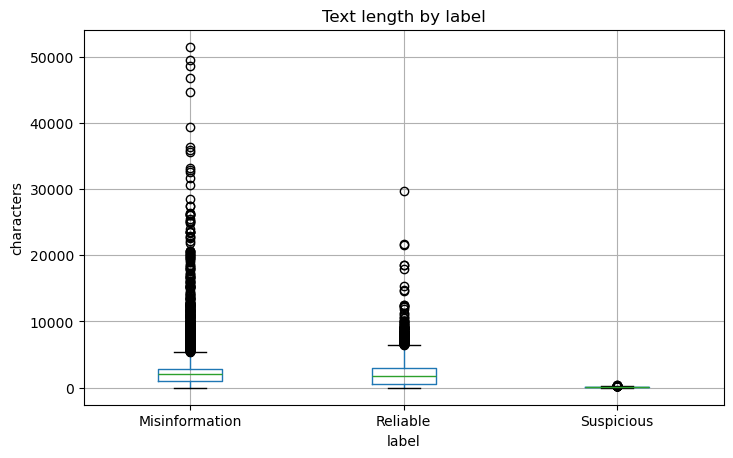

In [38]:
final_df.boxplot(column="text_length", by="label", figsize=(8,5))
plt.suptitle("")
plt.title("Text length by label")
plt.ylabel("characters")
plt.show()

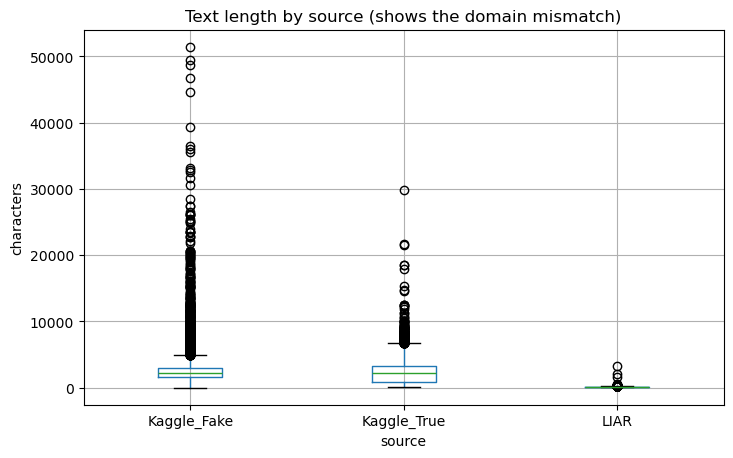

In [39]:
final_df.boxplot(column="text_length", by="source", figsize=(8,5))
plt.suptitle("")
plt.title("Text length by source (shows the domain mismatch)")
plt.ylabel("characters")
plt.show()


In [40]:
print(final_df.isnull().sum())

text           0
label          0
source         0
raw_text       0
label_id       0
text_length    0
clean_text     0
dtype: int64


In [41]:
train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42,
    stratify=final_df["label"]
)

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
Reliable          19859
Misinformation    16178
Suspicious         3010
Name: count, dtype: int64
label
Reliable          4965
Misinformation    4045
Suspicious         752
Name: count, dtype: int64


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

vectorizer = TfidfVectorizer(max_features=50000, stop_words="english")

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train, train_df["label_id"])

preds = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(test_df["label_id"], preds))
print(classification_report(
    test_df["label_id"], preds,
    target_names=["Reliable", "Suspicious", "Misinformation"]
))

Accuracy: 0.8552550706822373
                precision    recall  f1-score   support

      Reliable       0.97      0.86      0.91      4965
    Suspicious       0.37      0.89      0.52       752
Misinformation       0.96      0.85      0.90      4045

      accuracy                           0.86      9762
     macro avg       0.77      0.86      0.78      9762
  weighted avg       0.92      0.86      0.88      9762



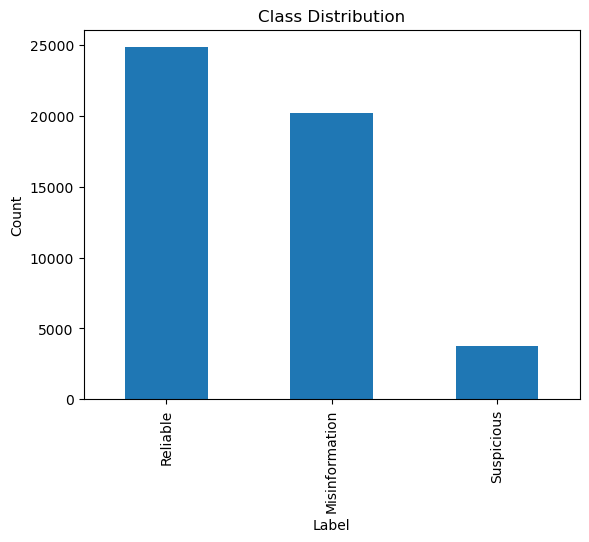

In [22]:
import matplotlib.pyplot as plt

final_df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [43]:
def predict_news(text):
    x = vectorizer.transform([clean_text(text)])
    pred = baseline_model.predict(x)[0]
    prob = baseline_model.predict_proba(x)[0]
    return {
        "prediction": id_to_label[pred],
        "confidence": round(max(prob), 3)
    }

predict_news("Government announces new education policy for students.")

{'prediction': 'Suspicious', 'confidence': np.float64(0.5)}

In [44]:
import os
os.makedirs("data/processed", exist_ok=True)

train_out = train_df[["text", "label", "source"]]
test_out = test_df[["text", "label", "source"]]

# further split train into train/val for the transformer training notebook
train_final, val_final = train_test_split(
    train_out, test_size=0.15, random_state=42, stratify=train_out["label"]
)

train_final.to_csv("data/processed/train.csv", index=False)
val_final.to_csv("data/processed/val.csv", index=False)
test_out.to_csv("data/processed/test.csv", index=False)

print("train:", train_final.shape)
print("val:  ", val_final.shape)
print("test: ", test_out.shape)

train: (33189, 3)
val:   (5858, 3)
test:  (9762, 3)


In [47]:
print(liar.isnull().sum())


id                      0
label                   0
statement               0
subject                 2
speaker                 2
speaker_job          2898
state                2210
party                   2
barely_true_count       2
false_count             2
half_true_count         2
mostly_true_count       2
pants_fire_count        2
context               102
new_label               0
dtype: int64
